# Data Collection

In [2]:
import pandas as pd
import os
import glob


import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import Counter
import re


In [35]:
# BLUESKY 
bsky_dir = "bluesky_posts"
bsky_files = glob.glob(os.path.join(bsky_dir, "*.csv"))

bsky_dfs = []
for f in bsky_files:
    try:
        df = pd.read_csv(f, encoding="utf-8")
        bsky_dfs.append(df)
    except:
        pass

if bsky_dfs:
    bsky_all = pd.concat(bsky_dfs, ignore_index=True)
    bsky_all = bsky_all.drop_duplicates(subset=["post_uri"], keep="first")
    print("BLUESKY SUMMARY")
    print(f"Total CSV files:      {len(bsky_files)}")
    print(f"Total unique posts:   {len(bsky_all):,}")
    print(f"Date range:           {bsky_all['created_at'].min()} → {bsky_all['created_at'].max()}")
    print(f"Unique authors:       {bsky_all['author_did'].nunique():,}")
    print(f"\nPosts per keyword:")
    print(bsky_all["search_keyword"].value_counts().to_string())
else:
    print("No Bluesky data found yet")



BLUESKY SUMMARY
Total CSV files:      2671
Total unique posts:   2,035,552
Date range:           2023-02-01T00:26:47 → 2026-05-29T08:56:14+09:00
Unique authors:       472,028

Posts per keyword:
search_keyword
AI                        670272
ChatGPT                   545277
GenAI                     148906
Midjourney                140769
pro-AI                    139168
AI slop                   106651
AI powered                 77733
AI agents                  61207
anti-AI                    52489
Deepfake                   45871
BigTech                    15874
AI data center              7406
AI Ethics                   6831
Claude AI                   5722
AI energy                   3024
AI hallucination            2621
polarization                2069
AI datacenter               1452
AI breakthrough             1129
AI water                     672
AI solve                     371
Artificial Intellgence        22
AI polarization               16


In [38]:
# TRUTH SOCIAL
truth_dir = "truth_posts"
truth_files = glob.glob(os.path.join(truth_dir, "truth_*.csv"))

truth_dfs = []
for f in truth_files:
    try:
        df = pd.read_csv(f, encoding="utf-8", dtype={"post_id": str})
        truth_dfs.append(df)
    except:
        pass

if truth_dfs:
    truth_all = pd.concat(truth_dfs, ignore_index=True)
    truth_all = truth_all.drop_duplicates(subset=["post_id"], keep="first")
    print("TRUTH SOCIAL SUMMARY")
    print(f"Total CSV files:      {len(truth_files)}")
    print(f"Total unique posts:   {len(truth_all):,}")
    print(f"Date range:           {truth_all['created_at'].min()} → {truth_all['created_at'].max()}")
    print(f"Unique authors:       {truth_all['author_id'].nunique():,}")
    print(f"\nPosts per hashtag:")
    print(truth_all["hashtag"].value_counts().to_string())
else:
    print("\nNo Truth Social data found yet")

TRUTH SOCIAL SUMMARY
Total CSV files:      19
Total unique posts:   50,875
Date range:           2022-02-15T17:04:41.144Z → 2026-05-19T16:08:33.224Z
Unique authors:       6,508

Posts per hashtag:
hashtag
AI                        22161
BigTech                   13361
ArtificialIntelligence     8554
ChatGPT                    3760
project2025                 985
deepfake                    834
Midjourney                  450
AIethics                    249
AIagents                    180
GenAI                        84
AIpowered                    82
AIdatacenter                 76
ClaudeAI                     61
AIslop                       23
AIenergy                      6
AIbreakthrough                3
AIhallucination               3
antiAI                        2
proAI                         1


### Visualize Data 


- time series - add vertical lines for big events
- engagement distribution - long tail? - long tail shows that not many of them received a lot of engagement
- Media Bias Fact Check - need to match the URL exactly - display url count in decending order to work around this - extract tiny.url to get actual link - small missmatch can be edited manually
- then can classify posts based on MBFC - see which ones use more of the verified sources (tiktok wont have many on MBFC - need to find another methodology)
- see how to quantify in favor of AI vs against AI
- ollama - open source llm - to classify 


introduction 
- frame the question in the context - env groups have expressed concern
- 


literature review 
- include table with key points and key quantifiable indicators
- walter quattro -- patterns models and challenges in online social media
- excho chmabers / polarization part

- want to see what people are saying on different social media platforms - from a diverse sample across platforms
- misinfromation dyanmics and polarization on social media - read this section 
- background - lots of polarixation studies on politics, not yet many on AI
- polarization around climate change? what are the most polarizing topics discussed on social media?
- growing poklariation around climate change on social media - studies done on traditional social media - no longer access to that data
- TABLE : reference, techniques, data, results / description
- spatio temporal crime hot spot detection and prediction - look at their section 

include data as subsection of introduction 
distribution table - keywords, hastags, number of users, posts etc. 


methodology 
- MBFC - media bias fact check to classify - distrubutuoin of reliable and questionable posts
- tik tok will be country wise 
- dataset composition
- try to quantify the most debated topics within these hashtags
- include data collection details / keywords discussion
- include visuals from preliminary data exploration
- MDFC, qwen2.5:14b model to classify 



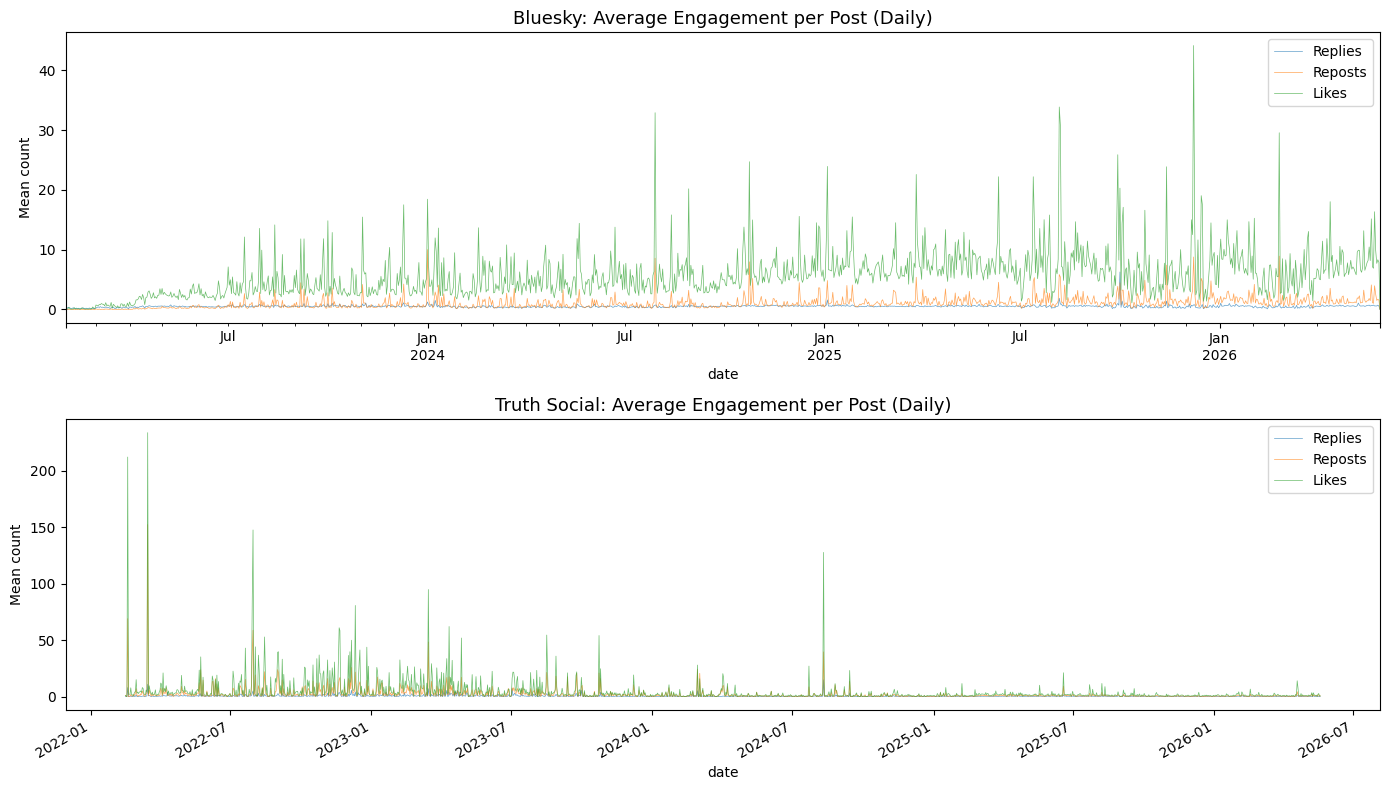

In [29]:
bsky_all['date'] = pd.to_datetime(bsky_all['created_at'], format='mixed', utc=True).dt.date
truth_all['date'] = pd.to_datetime(truth_all['created_at'], format='mixed', utc=True).dt.date


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Bluesky daily mean engagement
bsky_eng = bsky_all.groupby('date')[['reply_count', 'repost_count', 'like_count']].mean()
bsky_eng.index = pd.to_datetime(bsky_eng.index)
bsky_eng.plot(ax=ax1, linewidth=0.5, alpha=0.7)
ax1.set_title('Bluesky: Average Engagement per Post (Daily)', fontsize=13)
ax1.set_ylabel('Mean count')
ax1.legend(['Replies', 'Reposts', 'Likes'])

# Truth Social daily mean engagement
truth_eng = truth_all.groupby('date')[['reply_count', 'retruth_count', 'like_count']].mean()
truth_eng.index = pd.to_datetime(truth_eng.index)
truth_eng.plot(ax=ax2, linewidth=0.5, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax2.set_title('Truth Social: Average Engagement per Post (Daily)', fontsize=13)
ax2.set_ylabel('Mean count')
ax2.legend(['Replies', 'Reposts', 'Likes'])

plt.tight_layout()
plt.show()

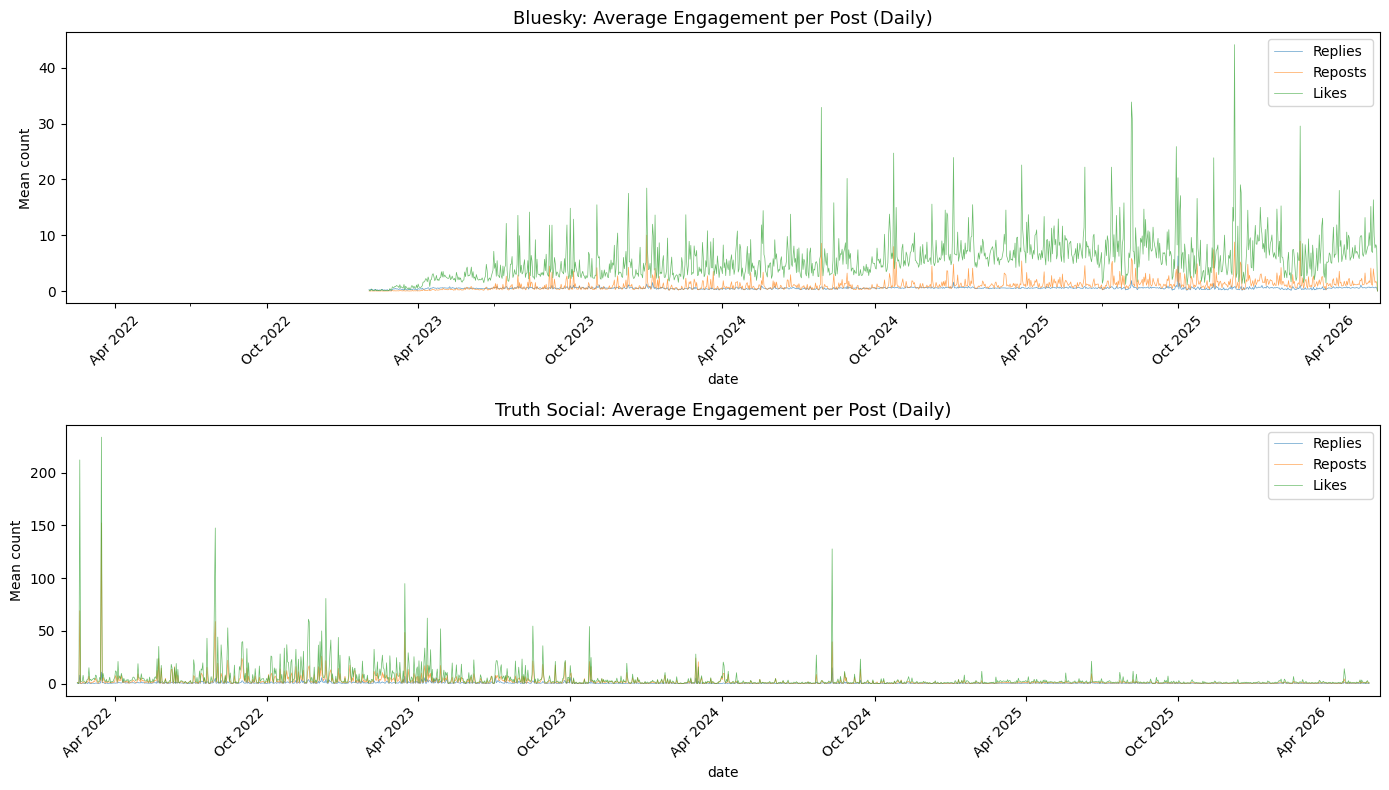

In [30]:




bsky_all['date'] = pd.to_datetime(bsky_all['created_at'], format='mixed', utc=True).dt.date
truth_all['date'] = pd.to_datetime(truth_all['created_at'], format='mixed', utc=True).dt.date


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Bluesky daily mean engagement
bsky_eng = bsky_all.groupby('date')[['reply_count', 'repost_count', 'like_count']].mean()
bsky_eng.index = pd.to_datetime(bsky_eng.index)
bsky_eng.plot(ax=ax1, linewidth=0.5, alpha=0.7)
ax1.set_title('Bluesky: Average Engagement per Post (Daily)', fontsize=13)
ax1.set_ylabel('Mean count')
ax1.legend(['Replies', 'Reposts', 'Likes'])


# date labels aligned 
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)



# Truth Social daily mean engagement
truth_eng = truth_all.groupby('date')[['reply_count', 'retruth_count', 'like_count']].mean()
truth_eng.index = pd.to_datetime(truth_eng.index)
truth_eng.plot(ax=ax2, linewidth=0.5, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax2.set_title('Truth Social: Average Engagement per Post (Daily)', fontsize=13)
ax2.set_ylabel('Mean count')
ax2.legend(['Replies', 'Reposts', 'Likes'])

# date labels aligned 
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)



# put one same timelines 
shared_xlim = (pd.Timestamp('2022-02-01'), pd.Timestamp('2026-06-01'))
ax1.set_xlim(shared_xlim)
ax2.set_xlim(shared_xlim)



plt.tight_layout()
plt.show()

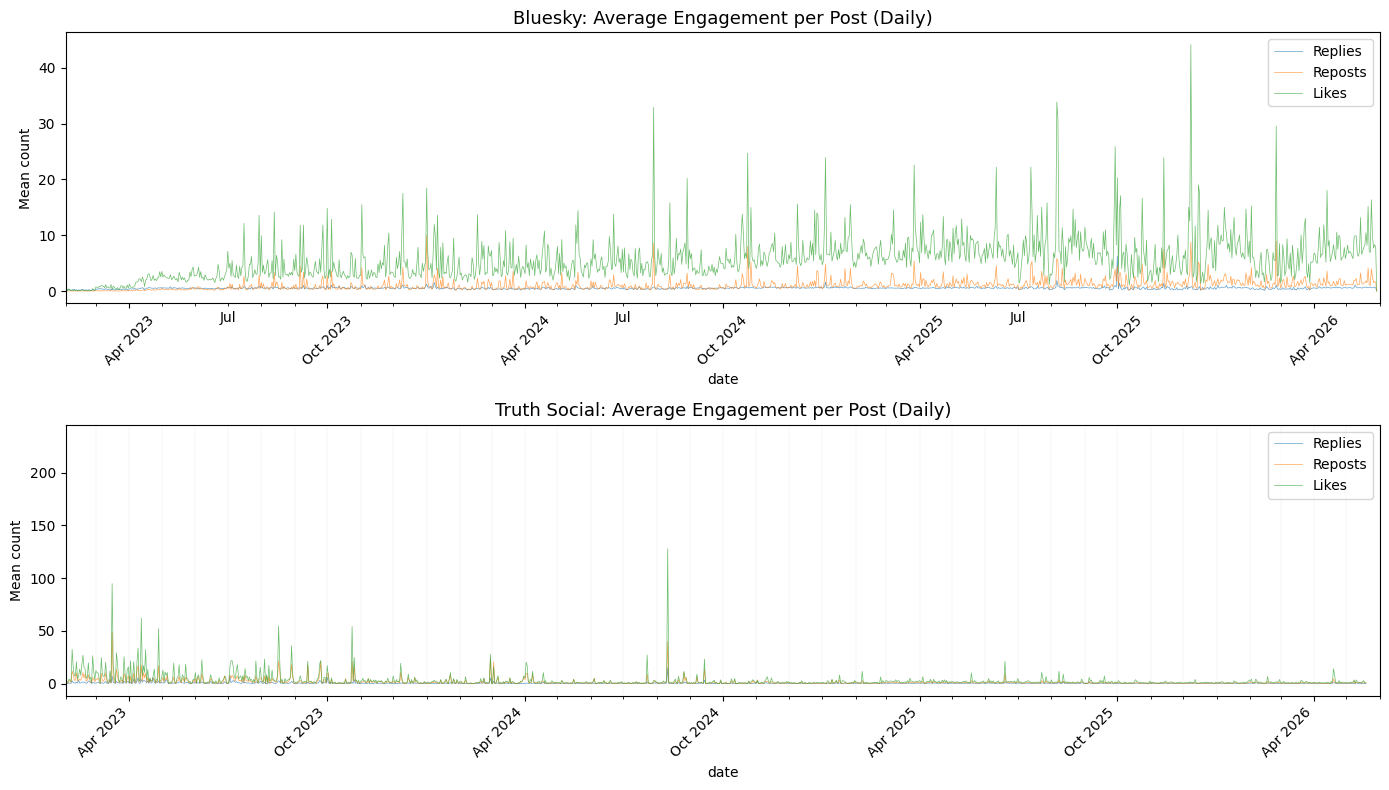

In [31]:




bsky_all['date'] = pd.to_datetime(bsky_all['created_at'], format='mixed', utc=True).dt.date
truth_all['date'] = pd.to_datetime(truth_all['created_at'], format='mixed', utc=True).dt.date


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Bluesky daily mean engagement
bsky_eng = bsky_all.groupby('date')[['reply_count', 'repost_count', 'like_count']].mean()
bsky_eng.index = pd.to_datetime(bsky_eng.index)
bsky_eng.plot(ax=ax1, linewidth=0.5, alpha=0.7)
ax1.set_title('Bluesky: Average Engagement per Post (Daily)', fontsize=13)
ax1.set_ylabel('Mean count')
ax1.legend(['Replies', 'Reposts', 'Likes'])


# date labels aligned 
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)



# Truth Social daily mean engagement
truth_eng = truth_all.groupby('date')[['reply_count', 'retruth_count', 'like_count']].mean()
truth_eng.index = pd.to_datetime(truth_eng.index)
truth_eng.plot(ax=ax2, linewidth=0.5, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax2.set_title('Truth Social: Average Engagement per Post (Daily)', fontsize=13)
ax2.set_ylabel('Mean count')
ax2.legend(['Replies', 'Reposts', 'Likes'])
ax2.grid(True, which='both', axis='x', linewidth=0.3, alpha=0.3)
ax2.xaxis.set_minor_locator(mdates.MonthLocator())

# date labels aligned 
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)



# put one same timelines 
shared_xlim = (pd.Timestamp('2023-02-01'), pd.Timestamp('2026-06-01'))
ax1.set_xlim(shared_xlim)
ax2.set_xlim(shared_xlim)



plt.tight_layout()
plt.show()

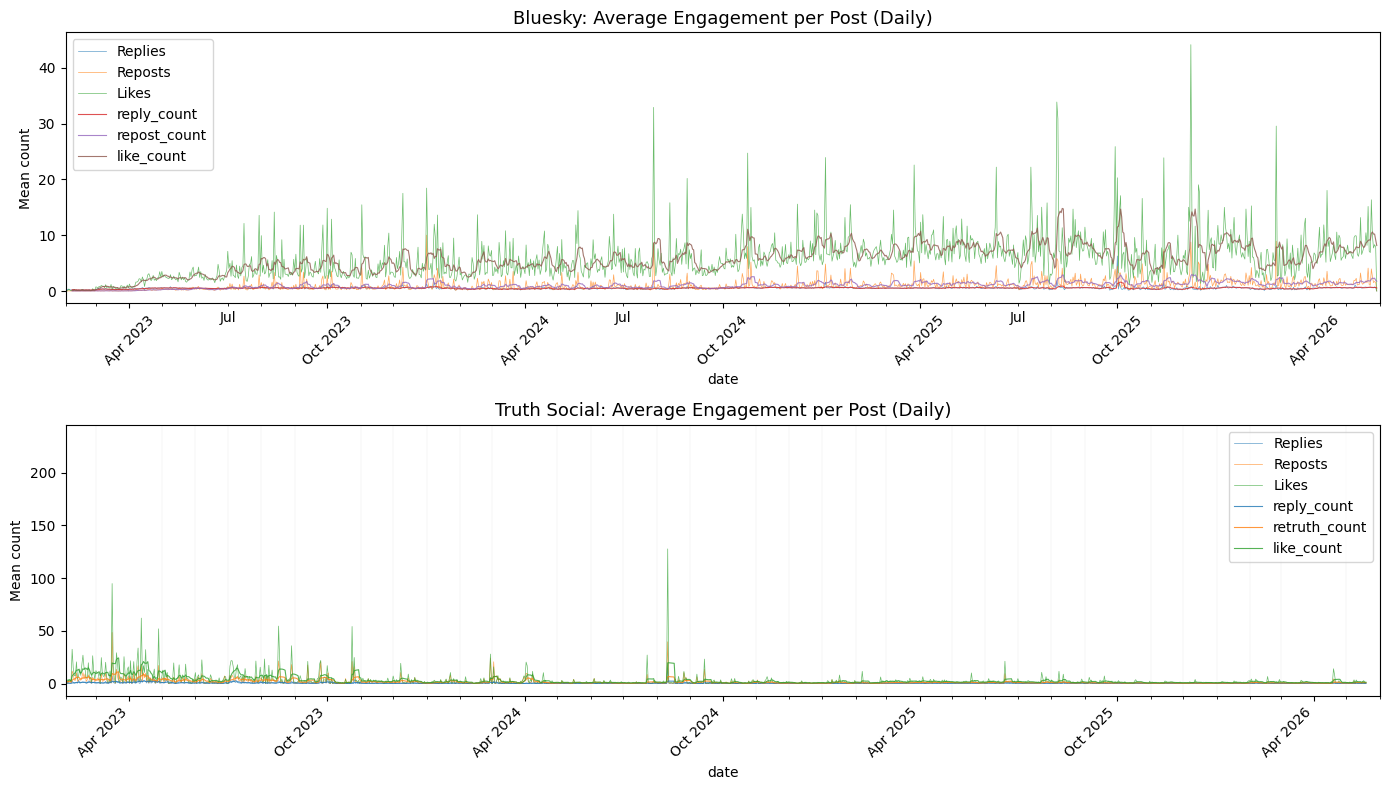

In [32]:




bsky_all['date'] = pd.to_datetime(bsky_all['created_at'], format='mixed', utc=True).dt.date
truth_all['date'] = pd.to_datetime(truth_all['created_at'], format='mixed', utc=True).dt.date


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Bluesky daily mean engagement
bsky_eng = bsky_all.groupby('date')[['reply_count', 'repost_count', 'like_count']].mean()
bsky_eng.index = pd.to_datetime(bsky_eng.index)
bsky_eng.plot(ax=ax1, linewidth=0.5, alpha=0.7)
ax1.set_title('Bluesky: Average Engagement per Post (Daily)', fontsize=13)
ax1.set_ylabel('Mean count')
ax1.legend(['Replies', 'Reposts', 'Likes'])

# rolling average to identify trends
bsky_eng.rolling(7).mean().plot(ax=ax1, linewidth=0.8, alpha=0.8)


# date labels aligned 
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)



# Truth Social daily mean engagement
truth_eng = truth_all.groupby('date')[['reply_count', 'retruth_count', 'like_count']].mean()
truth_eng.index = pd.to_datetime(truth_eng.index)
truth_eng.plot(ax=ax2, linewidth=0.5, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax2.set_title('Truth Social: Average Engagement per Post (Daily)', fontsize=13)
ax2.set_ylabel('Mean count')
ax2.legend(['Replies', 'Reposts', 'Likes'])
ax2.grid(True, which='both', axis='x', linewidth=0.3, alpha=0.3)
ax2.xaxis.set_minor_locator(mdates.MonthLocator())


# rolling average to identify trends
truth_eng.rolling(7).mean().plot(ax=ax2, linewidth=0.8, alpha=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

# date labels aligned 
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)



# put one same timelines 
shared_xlim = (pd.Timestamp('2023-02-01'), pd.Timestamp('2026-06-01'))
ax1.set_xlim(shared_xlim)
ax2.set_xlim(shared_xlim)



plt.tight_layout()
plt.show()

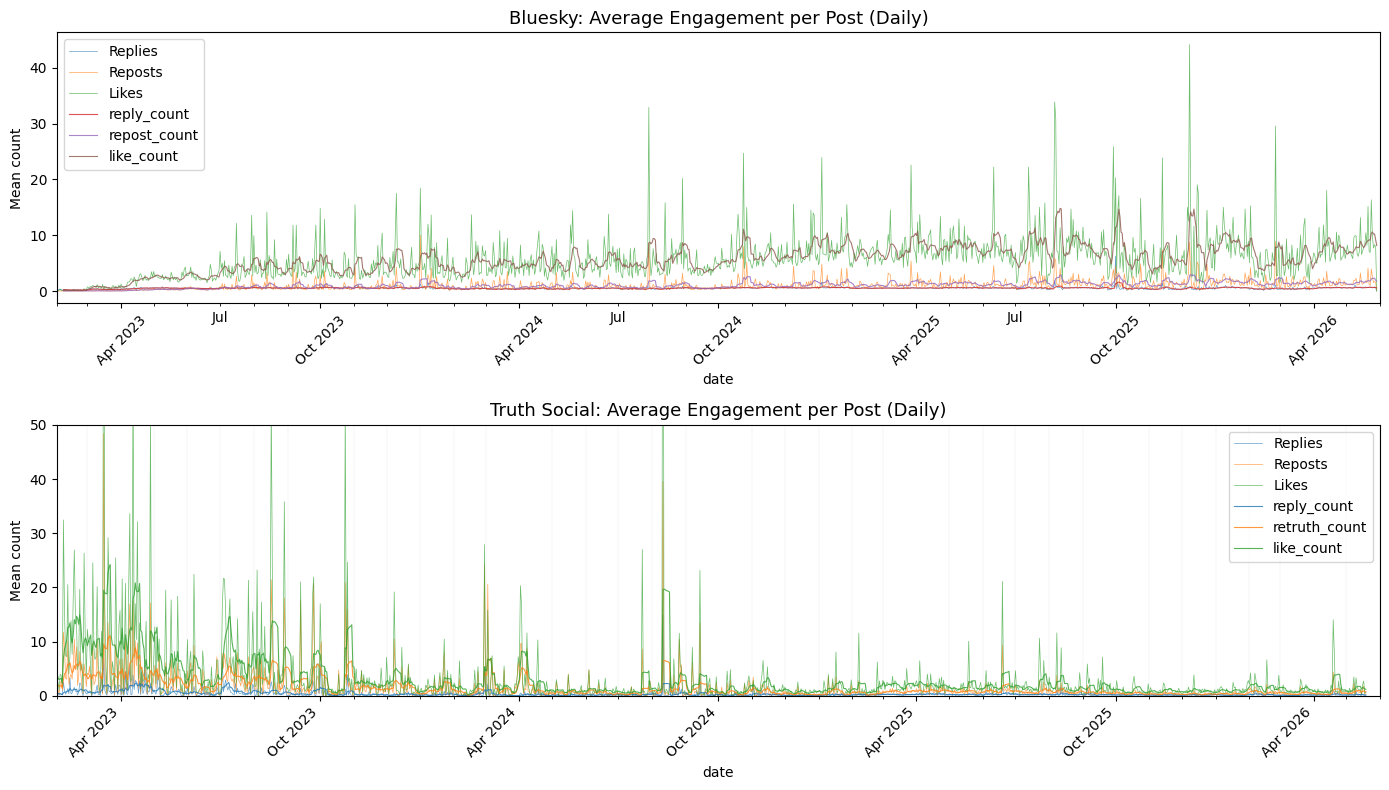

In [33]:




bsky_all['date'] = pd.to_datetime(bsky_all['created_at'], format='mixed', utc=True).dt.date
truth_all['date'] = pd.to_datetime(truth_all['created_at'], format='mixed', utc=True).dt.date


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Bluesky daily mean engagement
bsky_eng = bsky_all.groupby('date')[['reply_count', 'repost_count', 'like_count']].mean()
bsky_eng.index = pd.to_datetime(bsky_eng.index)
bsky_eng.plot(ax=ax1, linewidth=0.5, alpha=0.7)
ax1.set_title('Bluesky: Average Engagement per Post (Daily)', fontsize=13)
ax1.set_ylabel('Mean count')
ax1.legend(['Replies', 'Reposts', 'Likes'])

# rolling average to identify trends
bsky_eng.rolling(7).mean().plot(ax=ax1, linewidth=0.8, alpha=0.8)


# date labels aligned 
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)



# Truth Social daily mean engagement
truth_eng = truth_all.groupby('date')[['reply_count', 'retruth_count', 'like_count']].mean()
truth_eng.index = pd.to_datetime(truth_eng.index)
truth_eng.plot(ax=ax2, linewidth=0.5, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax2.set_title('Truth Social: Average Engagement per Post (Daily)', fontsize=13)
ax2.set_ylabel('Mean count')
ax2.legend(['Replies', 'Reposts', 'Likes'])
ax2.grid(True, which='both', axis='x', linewidth=0.3, alpha=0.3)
ax2.xaxis.set_minor_locator(mdates.MonthLocator())
ax2.set_ylim(0, 50)


# rolling average to identify trends
truth_eng.rolling(7).mean().plot(ax=ax2, linewidth=0.8, alpha=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

# date labels aligned 
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)



# put one same timelines 
shared_xlim = (pd.Timestamp('2023-02-01'), pd.Timestamp('2026-06-01'))
ax1.set_xlim(shared_xlim)
ax2.set_xlim(shared_xlim)



plt.tight_layout()
plt.show()

## REPOSTS AND COMMENTS 




In [39]:
def load_csvs(directory, pattern="*.csv", dedup_col=None, id_dtype=None):
    files = glob.glob(os.path.join(directory, pattern))
    dfs = []
    for f in files:
        try:
            dtype = {id_dtype: str} if id_dtype else None
            dfs.append(pd.read_csv(f, encoding="utf-8", dtype=dtype))
        except:
            pass
    if not dfs:
        return pd.DataFrame(), len(files)
    combined = pd.concat(dfs, ignore_index=True)
    if dedup_col and dedup_col in combined.columns:
        combined = combined.drop_duplicates(subset=[dedup_col], keep="first")
    return combined, len(files)

# BLUESKY POSTS
bsky_posts, n = load_csvs("bluesky_posts", dedup_col="post_uri")
if not bsky_posts.empty:
    print("BLUESKY POSTS")
    print(f"  CSV files:        {n}")
    print(f"  Unique posts:     {len(bsky_posts):,}")
    print(f"  Unique authors:   {bsky_posts['author_did'].nunique():,}")
    print(f"  Date range:       {bsky_posts['created_at'].min()} → {bsky_posts['created_at'].max()}")

# BLUESKY COMMENTS
bsky_comments, n = load_csvs("bluesky_comments", dedup_col="comment_uri")
if not bsky_comments.empty:
    print("BLUESKY COMMENTS")
    print(f"  CSV files:        {n}")
    print(f"  Unique comments:  {len(bsky_comments):,}")
    print(f"  Unique authors:   {bsky_comments['author_did'].nunique():,}")
    print(f"  Root posts covered: {bsky_comments['root_post_uri'].nunique():,}")
    print(f"  Max depth:        {bsky_comments['depth'].max()}")
else:
    print("\nNo Bluesky comments found")

# BLUESKY REPOSTS
bsky_reposts, n = load_csvs("bluesky_reposts")
if not bsky_reposts.empty:
    print("BLUESKY REPOSTS")
    print(f"  CSV files:        {n}")
    print(f"  Total reposts:    {len(bsky_reposts):,}")
    print(f"  Unique reposters: {bsky_reposts['reposted_by_did'].nunique():,}")
    print(f"  Posts covered:    {bsky_reposts['post_uri'].nunique():,}")
else:
    print("\nNo Bluesky reposts found")

# TRUTH SOCIAL POSTS
truth_posts, n = load_csvs("truth_posts", pattern="truth_*.csv", dedup_col="post_id", id_dtype="post_id")
if not truth_posts.empty:
    print("TRUTH SOCIAL POSTS")
    print(f"  CSV files:        {n}")
    print(f"  Unique posts:     {len(truth_posts):,}")
    print(f"  Unique authors:   {truth_posts['author_id'].nunique():,}")
    print(f"  Date range:       {truth_posts['created_at'].min()} → {truth_posts['created_at'].max()}")

# TRUTH SOCIAL COMMENTS
truth_comments, n = load_csvs("truth_comments", dedup_col="comment_id")
if not truth_comments.empty:
    print("TRUTH SOCIAL COMMENTS")
    print(f"  CSV files:        {n}")
    print(f"  Unique comments:  {len(truth_comments):,}")
    print(f"  Unique authors:   {truth_comments['author_handle'].nunique():,}")
    print(f"  Root posts covered: {truth_comments['root_post_id'].nunique():,}")
else:
    print("\nNo Truth Social comments found")

# TRUTH SOCIAL REPOSTS
truth_reposts, n = load_csvs("truth_reposts")
if not truth_reposts.empty:
    print("TRUTH SOCIAL REPOSTS")
    print(f"  CSV files:        {n}")
    print(f"  Total reposts:    {len(truth_reposts):,}")
    print(f"  Unique reposters: {truth_reposts['retruthed_by_id'].nunique():,}")
    print(f"  Posts covered:    {truth_reposts['post_id'].nunique():,}")
else:
    print("\nNo Truth Social reposts found")

BLUESKY POSTS
  CSV files:        2671
  Unique posts:     2,035,552
  Unique authors:   472,028
  Date range:       2023-02-01T00:26:47 → 2026-05-29T08:56:14+09:00
BLUESKY COMMENTS
  CSV files:        3034
  Unique comments:  1,280,633
  Unique authors:   287,431
  Root posts covered: 147,386
  Max depth:        9
BLUESKY REPOSTS
  CSV files:        1566
  Total reposts:    2,095,836
  Unique reposters: 416,050
  Posts covered:    155,468
TRUTH SOCIAL POSTS
  CSV files:        19
  Unique posts:     50,875
  Unique authors:   6,508
  Date range:       2022-02-15T17:04:41.144Z → 2026-05-19T16:08:33.224Z
TRUTH SOCIAL COMMENTS
  CSV files:        1
  Unique comments:  4,403
  Unique authors:   3,351
  Root posts covered: 2,194
TRUTH SOCIAL REPOSTS
  CSV files:        52
  Total reposts:    34,266
  Unique reposters: 15,722
  Posts covered:    5,082


## EDGE LISTS

In [7]:


CLEAN = 'clean'

# Load MBFC
mbfc = pd.read_csv('Factual-Reporting-and-Political-Bias-Web-Interactions/data/mbfc.csv')
mbfc_lookup = dict(zip(mbfc['source'], mbfc[['bias', 'factual_reporting']].to_dict('records')))

def extract_urls(text):
    if pd.isna(text):
        return []
    return re.findall(r'https?://[^\s<>"{}|\\^`\[\]]+', str(text))

def extract_domain(url):
    try:
        domain = urlparse(url).netloc.lower()
        return domain[4:] if domain.startswith('www.') else domain
    except:
        return None

def get_author_mbfc(posts_df, author_col, text_col='text'):
    """For each author, find their dominant MBFC bias and factuality based on URLs they share."""
    records = []
    for author, group in posts_df.groupby(author_col):
        bias_counts = Counter()
        fact_counts = Counter()
        for text in group[text_col]:
            for url in extract_urls(text):
                d = extract_domain(url)
                if d and d in mbfc_lookup:
                    bias_counts[mbfc_lookup[d]['bias']] += 1
                    fact_counts[mbfc_lookup[d]['factual_reporting']] += 1
        records.append({
            author_col: author,
            'mbfc_bias': bias_counts.most_common(1)[0][0] if bias_counts else None,
            'mbfc_factuality': fact_counts.most_common(1)[0][0] if fact_counts else None,
            'mbfc_sources_count': sum(bias_counts.values()),
        })
    return pd.DataFrame(records)

In [3]:
# Load edge lists and author MBFC profiles
bsky_edges = pd.read_csv('clean/bsky_repost_edgelist.csv')
truth_edges = pd.read_csv('clean/truth_repost_edgelist.csv', dtype={'source': str, 'target': str})

# Bluesky - add source and target MBFC attributes
bsky_edges = bsky_edges.merge(
    bsky_author_mbfc.rename(columns={'author_did': 'source', 'mbfc_bias': 'source_bias', 'mbfc_factuality': 'source_factuality', 'mbfc_sources_count': 'source_mbfc_count'}),
    on='source', how='left'
).merge(
    bsky_author_mbfc.rename(columns={'author_did': 'target', 'mbfc_bias': 'target_bias', 'mbfc_factuality': 'target_factuality', 'mbfc_sources_count': 'target_mbfc_count'}),
    on='target', how='left'
)
bsky_edges.to_csv('clean/bsky_repost_edgelist_updated.csv', index=False)
print(f"Bluesky edges: {len(bsky_edges):,}")
print(bsky_edges.head())

# Truth Social - same
truth_edges = truth_edges.merge(
    truth_author_mbfc.rename(columns={'author_id': 'source', 'mbfc_bias': 'source_bias', 'mbfc_factuality': 'source_factuality', 'mbfc_sources_count': 'source_mbfc_count'}),
    on='source', how='left'
).merge(
    truth_author_mbfc.rename(columns={'author_id': 'target', 'mbfc_bias': 'target_bias', 'mbfc_factuality': 'target_factuality', 'mbfc_sources_count': 'target_mbfc_count'}),
    on='target', how='left'
)
truth_edges.to_csv('clean/truth_repost_edgelist_updated.csv', index=False)
print(f"Truth edges: {len(truth_edges):,}")
print(truth_edges.head())

NameError: name 'bsky_author_mbfc' is not defined

In [10]:
# BLUESKY  enrich edge list
bsky_posts = pd.read_csv(f'{CLEAN}/bsky_posts_clean.csv', usecols=['author_did', 'text'])
bsky_edges = pd.read_csv(f'{CLEAN}/bsky_repost_edgelist.csv')


bsky_author_mbfc = get_author_mbfc(bsky_posts, 'author_did')
classified = bsky_author_mbfc[bsky_author_mbfc['mbfc_bias'].notna()]
print(f"Authors with MBFC profile: {len(classified):,} / {len(bsky_author_mbfc):,}")

# Create node list with attributes
all_nodes = set(bsky_edges['source']) | set(bsky_edges['target'])
bsky_nodes = pd.DataFrame({'node_id': list(all_nodes)})
bsky_nodes = bsky_nodes.merge(
    bsky_author_mbfc.rename(columns={'author_did': 'node_id'}),
    on='node_id', how='left'
)
bsky_nodes.to_csv(f'{CLEAN}/bsky_repost_nodes.csv', index=False)
print(f"Saved bsky_repost_nodes.csv: {len(bsky_nodes):,} nodes")
print(f"  Bias: {bsky_nodes['mbfc_bias'].value_counts().to_dict()}")
print(f"  Factuality: {bsky_nodes['mbfc_factuality'].value_counts().to_dict()}")

del bsky_posts

Computing MBFC profiles for Bluesky authors...
Authors with MBFC profile: 0 / 341,317
Saved bsky_repost_nodes.csv: 377,014 nodes
  Bias: {}
  Factuality: {}


In [11]:
# TRUTH SOCIAL enrich edge list
truth_posts = pd.read_csv(f'{CLEAN}/truth_posts_clean.csv', usecols=['author_id', 'text'], dtype={'author_id': str})
truth_edges = pd.read_csv(f'{CLEAN}/truth_repost_edgelist.csv', dtype={'source': str, 'target': str})


truth_author_mbfc = get_author_mbfc(truth_posts, 'author_id')
classified = truth_author_mbfc[truth_author_mbfc['mbfc_bias'].notna()]
print(f"Authors with MBFC profile: {len(classified):,} / {len(truth_author_mbfc):,}")

all_nodes_t = set(truth_edges['source']) | set(truth_edges['target'])
truth_nodes = pd.DataFrame({'node_id': list(all_nodes_t)})
truth_nodes = truth_nodes.merge(
    truth_author_mbfc.rename(columns={'author_id': 'node_id'}),
    on='node_id', how='left'
)
truth_nodes.to_csv(f'{CLEAN}/truth_repost_nodes.csv', index=False)
print(f"Saved truth_repost_nodes.csv: {len(truth_nodes):,} nodes")
print(f"  Bias: {truth_nodes['mbfc_bias'].value_counts().to_dict()}")
print(f"  Factuality: {truth_nodes['mbfc_factuality'].value_counts().to_dict()}")

del truth_posts

Authors with MBFC profile: 0 / 6,276
Saved truth_repost_nodes.csv: 15,993 nodes
  Bias: {}
  Factuality: {}
